<a href="https://colab.research.google.com/github/Arrox1627/Earnings-Call-Tone/blob/main/earnings_sentiment_backtestV3%20proscessed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Earnings Call Sentiment Backtest
**Does management's tone on an earnings call predict how the stock moves afterwards?**

This notebook uses the free *Stock Values and Earnings Call Transcripts* dataset (Roozen & Lelli, Tilburg University, CC0): **188 earnings calls from 10 NASDAQ companies, 2016–2020**, with matching daily stock prices and the NASDAQ index.

It scores every sentence with **FinBERT** (a free, open-source model trained on financial text), then tests whether more positive calls are followed by better stock performance *relative to the NASDAQ*.

No API keys needed.

### How to run it
1. **Runtime → Change runtime type → T4 GPU.** Scoring about 75,000 sentences takes a few minutes on a GPU and could take an hour or more without one.
2. **Runtime → Run all.**
3. When the upload button appears in step 2, select the **.zip file** you downloaded from DataverseNL (don't unzip it first).

## 1. Install and import

In [6]:
!pip install -q transformers statsmodels

import re, os, glob, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from tqdm.auto import tqdm
from transformers import pipeline
import torch

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 140)
BLUE, ORANGE, GREY, DARK = "#2F6DB5", "#E07B1F", "#9AA3B2", "#2B2F36"
plt.rcParams.update({"figure.dpi": 130, "font.size": 11, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
print("GPU available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    print("⚠️  No GPU: switch to Runtime → Change runtime type → T4 GPU, or step 4 will be very slow.")

GPU available: True


## 2. Upload the dataset
Select the `.zip` file from DataverseNL. (If you already unzipped it, you can instead upload the loose `.txt` and `.csv` files.)

In [7]:
from google.colab import files
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

uploaded = files.upload()
for name, content in uploaded.items():
    path = os.path.join(DATA_DIR, name)
    with open(path, "wb") as f:
        f.write(content)
    if name.lower().endswith(".zip"):
        with zipfile.ZipFile(path) as z:
            z.extractall(DATA_DIR)
        # Dataverse sometimes nests zips inside the zip
        for inner in glob.glob(os.path.join(DATA_DIR, "**", "*.zip"), recursive=True):
            if os.path.abspath(inner) != os.path.abspath(path):
                with zipfile.ZipFile(inner) as z:
                    z.extractall(os.path.dirname(inner))

FILE_RE = re.compile(r"(\d{4})-([A-Za-z]{3})-(\d{2})-([A-Z.]+)\.txt$")
transcript_paths = sorted(p for p in glob.glob(os.path.join(DATA_DIR, "**", "*.txt"), recursive=True)
                          if FILE_RE.search(os.path.basename(p)))
price_paths = {os.path.splitext(os.path.basename(p))[0].upper(): p
               for p in glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True)}

print(f"Found {len(transcript_paths)} transcripts and {len(price_paths)} price files: {sorted(price_paths)}")
assert transcript_paths, "No transcripts found. Check you uploaded the dataset zip."
assert "NASDAQ" in price_paths, "NASDAQ.csv (the benchmark) is missing from the upload."

Saving doi-10.34894-tje0d0.zip to doi-10.34894-tje0d0 (1).zip
Found 188 transcripts and 11 price files: ['AAPL', 'AMD', 'AMZN', 'ASML', 'CSCO', 'GOOGL', 'INTC', 'MSFT', 'MU', 'NASDAQ', 'NVDA']


## 3. Parse the transcripts
The dataset contains two document types. Most files are **full transcripts** with verbatim speech. A few (most of Apple's later calls) are **Event Briefs**, where the presentation section is a condensed third-party summary in note form rather than management's own words; their Q&A is still verbatim. The parser detects which is which, and the summary sections are excluded from all tone measures.

Each transcript is split into **prepared remarks** and **Q&A**, and every passage is tagged by speaker role:
- **Management**: people listed under *Corporate Participants* (CEO, CFO, IR).
- **Analysts**: everyone asking questions.
- **Operator**: ignored.

The notebook also reads the call time (in GMT) so it knows whether the call happened **after the US market closed** or **before it opened**. That determines which trading day's move is the market's reaction.

In [8]:
HEADER_RE = re.compile(r"^(.+?)\s+\[\d+\]\s*$")
DASHES = re.compile(r"\n\s*-{20,}\s*\n")
SYNC = re.compile(r"<Sync[^>]*/>")

def detect_format(raw):
    # Full StreetEvents transcript, or a condensed Event Brief (most of Apple's later calls)
    return "brief" if ("\nQUESTIONS AND ANSWERS\n" in raw or "Event Brief" in raw) else "full"

def parse_transcript(path):
    raw = open(path, encoding="utf-8", errors="ignore").read().replace("\r", "")
    raw = SYNC.sub("", raw.split("\nDisclaimer\n")[0])
    fmt = detect_format(raw)
    m = re.search(r"\n([A-Z][^\n]*(?:Earnings|Results)[^\n]*Call[^\n]*)\n", raw)
    title = m.group(1).strip() if m else os.path.basename(path)
    t = re.search(r"([A-Z]+) (\d{1,2}), (\d{4}) / (\d{1,2}):(\d{2})\s*(AM|PM) GMT", raw)
    gmt_hour = None
    if t:
        gmt_hour = int(t.group(4)) % 12 + (12 if t.group(6) == "PM" else 0) + int(t.group(5)) / 60

    mgmt = set()
    cp = re.search(r"Corporate Participants\s*\n=+\n(.*?)\n=+", raw, re.S)
    if cp:
        for line in cp.group(1).split("\n"):
            if line.strip().startswith("*"):
                mgmt.add(line.strip().lstrip("* ").strip().lower())

    pres_h, qa_h = ("\nPRESENTATION SUMMARY\n", "\nQUESTIONS AND ANSWERS\n") if fmt == "brief" \
                   else ("\nPresentation\n", "\nQuestions and Answers\n")
    qa_idx, pres_idx = raw.find(qa_h), raw.find(pres_h)
    sections = [("Prepared remarks", raw[pres_idx:qa_idx if qa_idx > 0 else None] if pres_idx >= 0 else ""),
                ("Q&A", raw[qa_idx:] if qa_idx > 0 else "")]
    blocks = []
    for section, text in sections:
        speaker = role = None
        for chunk in DASHES.split(text):
            c = chunk.strip()
            if not c or c.startswith("=") or c.strip("= \n").upper() in ("PRESENTATION", "PRESENTATION SUMMARY", "QUESTIONS AND ANSWERS"):
                continue
            h = HEADER_RE.match(c) if "\n" not in c else None
            if h:
                speaker = h.group(1).strip()
                name = speaker.split(",")[0].strip().lower()
                if name in ("operator", "unidentified participant", "unidentified company representative"):
                    role = "operator"
                elif name in mgmt or (not mgmt and "Research Division" not in speaker):
                    role = "management"
                else:
                    role = "analyst"
                continue
            if speaker:
                blocks.append({"section": section, "role": role, "text": re.sub(r"\s+", " ", c)})
    return fmt, title, gmt_hour, blocks

def split_sentences(text):
    sents = re.split(r"(?<=[.!?])\s+(?=[A-Z\"'])", text)
    return [s.strip() for s in sents if len(s.split()) >= 6 and "(Operator Instructions)" not in s]

def timing(gmt_hour):
    if gmt_hour is None: return "unknown"
    if gmt_hour >= 20:   return "after close"     # US market closes 20:00-21:00 GMT
    if gmt_hour < 13.5:  return "before open"     # US market opens 13:30-14:30 GMT
    return "during market"

events, sentence_rows = [], []
for p in tqdm(transcript_paths, desc="Parsing"):
    y, mon, d, ticker = FILE_RE.search(os.path.basename(p)).groups()
    date = pd.Timestamp(f"{y}-{mon}-{d}")
    fmt, title, gmt_hour, blocks = parse_transcript(p)
    eid = len(events)
    events.append({"event_id": eid, "ticker": ticker, "date": date, "title": title, "format": fmt,
                   "call_time_gmt": gmt_hour, "timing": timing(gmt_hour)})
    for b in blocks:
        if b["role"] == "operator":
            continue
        for s in split_sentences(b["text"]):
            sentence_rows.append({"event_id": eid, "section": b["section"], "role": b["role"], "sentence": s})

events = pd.DataFrame(events)
sentences = pd.DataFrame(sentence_rows)
counts = sentences.groupby("event_id").size()
events["n_sentences"] = events["event_id"].map(counts).fillna(0).astype(int)

print(f"{len(events)} calls, {len(sentences):,} sentences")
print("Formats:", events["format"].value_counts().to_dict())
empty = events[events["n_sentences"] == 0]
if len(empty):
    print("\n\u26a0\ufe0f  Transcripts that produced NO sentences (check the parser):")
    print(empty[["ticker", "date", "format"]].to_string(index=False))
else:
    print("No empty transcripts.")
print("\nCall timing:", events["timing"].value_counts().to_dict())
print("Sentences by speaker:", sentences.groupby(["section", "role"]).size().to_dict())

Parsing:   0%|          | 0/188 [00:00<?, ?it/s]

188 calls, 68,228 sentences
Formats: {'full': 171, 'brief': 17}
No empty transcripts.

Call timing: {'after close': 169, 'before open': 14, 'during market': 5}
Sentences by speaker: {('Prepared remarks', 'analyst'): 7, ('Prepared remarks', 'management'): 22250, ('Q&A', 'analyst'): 12702, ('Q&A', 'management'): 33269}


## 4. Score every sentence with FinBERT
Each sentence gets a probability of being positive, negative or neutral. Results are saved to `sentence_scores.csv`, so if the runtime disconnects you can re-upload that file instead of re-scoring.

In [9]:
CACHE = "sentence_scores.csv"
if os.path.exists(CACHE) and len(pd.read_csv(CACHE)) == len(sentences):
    scores = pd.read_csv(CACHE)
    print("Loaded cached scores.")
else:
    finbert = pipeline("text-classification", model="ProsusAI/finbert", top_k=None, truncation=True,
                       max_length=256, device=0 if torch.cuda.is_available() else -1)
    texts, out, BATCH = sentences["sentence"].tolist(), [], 1024
    for i in tqdm(range(0, len(texts), BATCH), desc="Scoring"):
        for r in finbert(texts[i:i + BATCH], batch_size=64):
            d = {x["label"]: x["score"] for x in r}
            out.append((d.get("positive", 0), d.get("negative", 0), d.get("neutral", 0)))
    scores = sentences.copy()
    scores[["positive", "negative", "neutral"]] = out
    scores.to_csv(CACHE, index=False)
scores["net"] = scores["positive"] - scores["negative"]
scores["label"] = scores[["positive", "negative", "neutral"]].idxmax(axis=1)
print(scores["label"].value_counts(normalize=True).round(3).to_dict())

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Scoring:   0%|          | 0/67 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


{'neutral': 0.603, 'positive': 0.325, 'negative': 0.071}


### Build the tone measures for each call
- **mgmt_tone**: net sentiment of everything management said (average positive − average negative, roughly −1 to +1)
- **remarks_tone**: management's scripted prepared remarks
- **answers_tone**: management's unscripted answers in Q&A
- **analyst_tone**: the analysts' questions (are they worried or upbeat?)
- **tone_change**: this call's mgmt_tone minus the same company's previous call. Markets often care more about *change* than level.

For Event Brief calls, `mgmt_tone` and `remarks_tone` are set to missing, because those files contain no verbatim prepared remarks. `answers_tone` and `analyst_tone` come from verbatim Q&A and are kept.

In [10]:
def tone(df):
    return df.groupby("event_id")["net"].mean()

mg = scores[scores["role"] == "management"]
events["mgmt_tone"] = events["event_id"].map(tone(mg))
events["remarks_tone"] = events["event_id"].map(tone(mg[mg["section"] == "Prepared remarks"]))
# Event Briefs carry no verbatim prepared remarks, so management-wide measures are not comparable
brief = events["format"] == "brief"
events.loc[brief, ["mgmt_tone", "remarks_tone"]] = np.nan
events["answers_tone"] = events["event_id"].map(tone(mg[mg["section"] == "Q&A"]))
events["analyst_tone"] = events["event_id"].map(tone(scores[scores["role"] == "analyst"]))
events["mgmt_pct_negative"] = events["event_id"].map(mg.assign(neg=mg["label"] == "negative").groupby("event_id")["neg"].mean())
events = events.sort_values(["ticker", "date"]).reset_index(drop=True)
events["tone_change"] = events.groupby("ticker")["mgmt_tone"].diff()
print("Calls with a management tone measure:", events["mgmt_tone"].notna().sum(), "of", len(events))
events[["ticker", "date", "format", "mgmt_tone", "remarks_tone", "answers_tone", "analyst_tone", "tone_change"]].round(3).head(12)

Calls with a management tone measure: 171 of 188


,ticker,date,format,mgmt_tone,remarks_tone,answers_tone,analyst_tone,tone_change
0,AAPL,2016-01-26,brief,NaN,NaN,0.156,0.013,NaN
1,AAPL,2016-04-26,full,0.258,0.326,0.181,-0.042,NaN
2,AAPL,2016-07-26,brief,NaN,NaN,0.171,-0.007,NaN
3,AAPL,2016-10-25,brief,NaN,NaN,0.220,0.006,NaN
4,AAPL,2017-01-31,brief,NaN,NaN,0.236,0.142,NaN
5,AAPL,2017-05-02,brief,NaN,NaN,0.193,0.071,NaN
6,AAPL,2017-08-01,brief,NaN,NaN,0.282,0.076,NaN
7,AAPL,2017-11-02,brief,NaN,NaN,0.227,0.165,NaN
8,AAPL,2018-02-01,brief,NaN,NaN,0.181,0.009,NaN
9,AAPL,2018-05-01,brief,NaN,NaN,0.262,0.079,NaN


## 5. Measure the market's reaction
For each call:
- **Reaction day** = the next trading day for after-close calls, or the same day for before-open calls.
- **Starting price** = the last close *before* the reaction day.
- Returns are measured over **1, 5 and 10 trading days**, using adjusted closing prices from the dataset.
- **Abnormal return** = the stock's return minus the NASDAQ's return over the same window. This removes general market moves, and it's the number that matters.

In [11]:
HORIZONS = [1, 5, 10]

def load_prices(path):
    df = pd.read_csv(path, parse_dates=["Date"])
    col = "Adj Close" if "Adj Close" in df.columns else "Close"
    return pd.Series(pd.to_numeric(df[col], errors="coerce").values, index=df["Date"]).dropna().sort_index()

def event_returns(series, call_date, when):
    react = series[series.index > call_date] if when == "after close" else series[series.index >= call_date]
    if len(react) < max(HORIZONS):
        return {h: np.nan for h in HORIZONS}
    base_s = series[series.index < react.index[0]]
    if base_s.empty:
        return {h: np.nan for h in HORIZONS}
    return {h: react.iloc[h - 1] / base_s.iloc[-1] - 1 for h in HORIZONS}

prices = {t: load_prices(p) for t, p in price_paths.items()}
nasdaq = prices["NASDAQ"]
for i, e in events.iterrows():
    if e["ticker"] not in prices:
        continue
    stock = event_returns(prices[e["ticker"]], e["date"], e["timing"])
    bench = event_returns(nasdaq, e["date"], e["timing"])
    for h in HORIZONS:
        events.loc[i, f"ret_{h}d"] = stock[h]
        events.loc[i, f"abn_{h}d"] = stock[h] - bench[h]

missing = events[events["abn_1d"].isna()]
print(f"Calls with price data: {events['abn_1d'].notna().sum()} / {len(events)}")
if len(missing):
    print("Missing:", missing[["ticker", "date"]].to_string(index=False))
(events[["ticker", "date", "mgmt_tone"] + [f"abn_{h}d" for h in HORIZONS]]
   .assign(**{f"abn_{h}d": lambda d, h=h: (d[f"abn_{h}d"] * 100).round(2) for h in HORIZONS}).head(10))

Calls with price data: 188 / 188


,ticker,date,mgmt_tone,abn_1d,abn_5d,abn_10d
0,AAPL,2016-01-26,NaN,-4.39,-4.40,2.06
1,AAPL,2016-04-26,0.258161,-5.74,-6.23,-8.33
2,AAPL,2016-07-26,NaN,5.91,7.54,10.91
3,AAPL,2016-10-25,NaN,-1.62,-3.26,-3.90
4,AAPL,2017-01-31,NaN,5.60,7.33,8.76
5,AAPL,2017-05-02,NaN,0.07,3.98,4.61
6,AAPL,2017-08-01,NaN,4.73,6.57,8.59
7,AAPL,2017-11-02,NaN,1.87,4.10,0.98
8,AAPL,2018-02-01,NaN,-2.38,0.71,5.28
9,AAPL,2018-05-01,NaN,4.84,8.11,7.58


## 6. Does tone predict returns?
Two correlation measures for each tone measure and horizon:
- **Pearson r**: linear relationship, sensitive to outliers.
- **Spearman ρ**: do more positive calls *rank* higher on returns? More robust.

**Watch out for multiple testing.** This table runs 15 tests, so at the usual p < 0.05 threshold you'd expect roughly one "significant" result by pure chance. The Bonferroni column shows the stricter bar (0.05 ÷ 15 ≈ 0.0033). Treat a result as convincing only if it's consistent across horizons and measures.

In [12]:
MEASURES = ["mgmt_tone", "remarks_tone", "answers_tone", "analyst_tone", "tone_change"]
rows = []
for m in MEASURES:
    for h in HORIZONS:
        d = events.dropna(subset=[m, f"abn_{h}d"])
        pr, pp = stats.pearsonr(d[m], d[f"abn_{h}d"])
        sr, sp = stats.spearmanr(d[m], d[f"abn_{h}d"])
        rows.append({"measure": m, "horizon": f"{h}d", "n": len(d),
                     "pearson_r": pr, "pearson_p": pp, "spearman_rho": sr, "spearman_p": sp})
corr = pd.DataFrame(rows)
N_TESTS = len(corr)
corr["significant (p<0.05)"] = np.where(corr["spearman_p"] < 0.05, "yes", "")
corr["survives Bonferroni"] = np.where(corr["spearman_p"] < 0.05 / N_TESTS, "yes", "")
corr.round(3)

,measure,horizon,n,pearson_r,pearson_p,spearman_rho,spearman_p,significant (p<0.05),survives Bonferroni
0,mgmt_tone,1d,171,0.036,0.643,0.086,0.263,,
1,mgmt_tone,5d,171,0.019,0.809,0.084,0.277,,
2,mgmt_tone,10d,171,0.010,0.900,0.047,0.545,,
3,remarks_tone,1d,171,0.060,0.434,0.143,0.062,,
4,remarks_tone,5d,171,0.082,0.286,0.161,0.035,yes,
5,remarks_tone,10d,171,0.070,0.363,0.141,0.066,,
6,answers_tone,1d,188,0.021,0.775,0.038,0.601,,
7,answers_tone,5d,188,-0.016,0.829,0.005,0.948,,
8,answers_tone,10d,188,-0.012,0.866,-0.017,0.815,,
9,analyst_tone,1d,188,0.331,0.000,0.356,0.000,yes,yes


## 6b. Regressions and robustness
Correlations treat every call as independent and ignore differences between firms. The main specification regresses the abnormal return on both tone measures at once, with firm fixed effects and standard errors clustered by firm. Tone measures are standardized, so each coefficient is the change in abnormal return (percentage points) per one-standard-deviation change in tone.

Note on inference: clustering leaves only ~10 clusters, which can understate uncertainty. Consistency across specifications matters more than any single p-value.

In [13]:
import statsmodels.formula.api as smf

reg = events.dropna(subset=["mgmt_tone", "analyst_tone", "abn_1d"]).copy()
for c in ["mgmt_tone", "analyst_tone", "remarks_tone", "answers_tone"]:
    reg[c + "_z"] = (reg[c] - reg[c].mean()) / reg[c].std()
for h in HORIZONS:
    reg[f"y{h}"] = reg[f"abn_{h}d"] * 100
    lo, hi = reg[f"y{h}"].quantile([0.01, 0.99])
    reg[f"w{h}"] = reg[f"y{h}"].clip(lo, hi)
reg["year"] = reg["date"].dt.year

def fit(formula, data, label):
    model = smf.ols(formula, data)
    n_clusters = data["ticker"].nunique()
    if n_clusters >= 3:
        m = model.fit(cov_type="cluster", cov_kwds={"groups": data["ticker"]})
    else:                      # too few firms to cluster on
        m = model.fit(cov_type="HC1")
        label += " (robust SE)"
    keep = [k for k in m.params.index if "C(" not in k and k != "Intercept"]
    return pd.DataFrame({"specification": label, "term": keep, "coef": m.params[keep].round(2),
                         "std_err": m.bse[keep].round(2), "p": m.pvalues[keep].round(4),
                         "n": int(m.nobs), "r2": round(m.rsquared, 3)}).reset_index(drop=True)

tables = [fit(f"y{h} ~ mgmt_tone_z + analyst_tone_z + C(ticker)", reg, f"Main, firm FE, {h}d") for h in HORIZONS]
tables += [
    fit("y1 ~ mgmt_tone_z + analyst_tone_z", reg, "No fixed effects, 1d"),
    fit("y1 ~ mgmt_tone_z + analyst_tone_z + C(ticker) + C(year)", reg, "Firm + year FE, 1d"),
    fit("w1 ~ mgmt_tone_z + analyst_tone_z + C(ticker)", reg, "Winsorized 1/99, 1d"),
    fit("y1 ~ mgmt_tone_z + analyst_tone_z + C(ticker)", reg[reg["y1"].abs() < reg["y1"].abs().quantile(0.95)],
        "Top 5% |return| dropped, 1d"),
    fit("y1 ~ remarks_tone_z + answers_tone_z + analyst_tone_z + C(ticker)", reg, "Management tone split, 1d"),
]
regression_table = pd.concat(tables, ignore_index=True)
regression_table

,specification,term,coef,std_err,p,n,r2
0,"Main, firm FE, 1d",mgmt_tone_z,-0.09,0.96,0.9227,171,0.156
1,"Main, firm FE, 1d",analyst_tone_z,3.38,1.08,0.0017,171,0.156
2,"Main, firm FE, 5d",mgmt_tone_z,0.11,1.07,0.9156,171,0.190
3,"Main, firm FE, 5d",analyst_tone_z,4.15,1.33,0.0018,171,0.190
4,"Main, firm FE, 10d",mgmt_tone_z,-0.11,1.28,0.9314,171,0.203
5,"Main, firm FE, 10d",analyst_tone_z,4.06,1.13,0.0003,171,0.203
6,"No fixed effects, 1d",mgmt_tone_z,-0.18,0.56,0.7490,171,0.120
7,"No fixed effects, 1d",analyst_tone_z,2.82,0.78,0.0003,171,0.120
8,"Firm + year FE, 1d",mgmt_tone_z,0.38,0.81,0.6362,171,0.168
9,"Firm + year FE, 1d",analyst_tone_z,3.32,1.00,0.0009,171,0.168


### Analyst tone, firm by firm
Is the analyst-tone result driven by one company?

In [14]:
per_firm = (reg.groupby("ticker")
              .apply(lambda g: pd.Series({"calls": len(g),
                                          "spearman_rho": stats.spearmanr(g["analyst_tone"], g["y1"])[0]}))
              .round(2).sort_values("spearman_rho", ascending=False))
print(f"Positive in {(per_firm['spearman_rho'] > 0).sum()} of {len(per_firm)} firms")
per_firm

Positive in 8 of 10 firms


,calls,spearman_rho
ticker,,
MU,17.0,0.49
GOOGL,19.0,0.48
CSCO,19.0,0.46
NVDA,19.0,0.45
MSFT,19.0,0.44
AMD,19.0,0.40
INTC,19.0,0.27
AMZN,19.0,0.24
ASML,19.0,-0.04


## 7. Charts for your LinkedIn post

### Chart 1: Most positive vs. least positive calls
Calls are split into three equal groups by management tone. The bars show the average return versus the NASDAQ after each group, with error bars (±1 standard error).

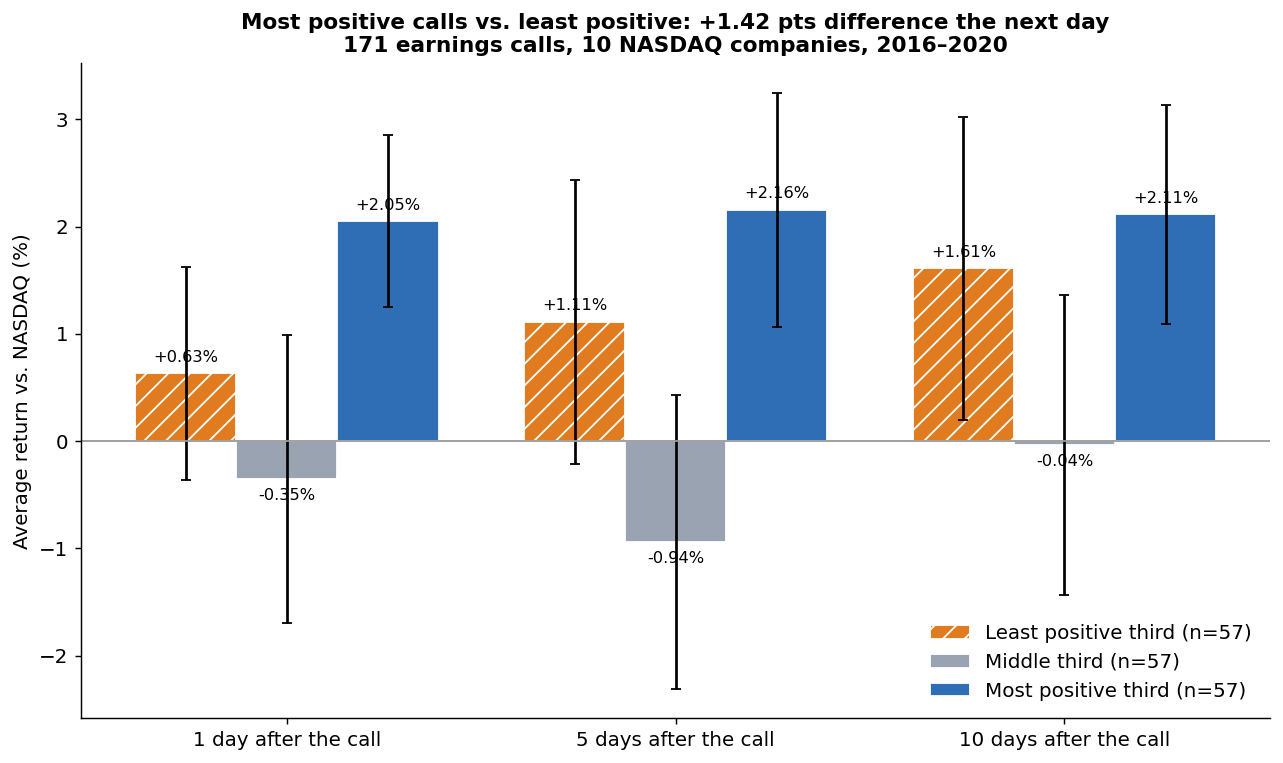

In [15]:
d = events.dropna(subset=["mgmt_tone", "abn_1d"]).copy()
d["tone_group"] = pd.qcut(d["mgmt_tone"], 3, labels=["Least positive third", "Middle third", "Most positive third"])
g = d.groupby("tone_group", observed=True)
means = pd.DataFrame({h: g[f"abn_{h}d"].mean() * 100 for h in HORIZONS})
sems = pd.DataFrame({h: g[f"abn_{h}d"].sem() * 100 for h in HORIZONS})

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(HORIZONS)); w = 0.26
styles = [(ORANGE, "//"), (GREY, ""), (BLUE, "")]
for k, (grp, (col, hatch)) in enumerate(zip(means.index, styles)):
    bars = ax.bar(x + (k - 1) * w, means.loc[grp], w, yerr=sems.loc[grp], capsize=3, color=col,
                  hatch=hatch, edgecolor="white", label=f"{grp} (n={g.size()[grp]})")
    for b, v in zip(bars, means.loc[grp]):
        ax.text(b.get_x() + b.get_width() / 2, v + (0.08 if v >= 0 else -0.08), f"{v:+.2f}%",
                ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
ax.axhline(0, color="#999", linewidth=1)
ax.set_xticks(x); ax.set_xticklabels([f"{h} day{'s' if h > 1 else ''} after the call" for h in HORIZONS])
ax.set_ylabel("Average return vs. NASDAQ (%)")
spread = means.loc["Most positive third", 1] - means.loc["Least positive third", 1]
ax.set_title(f"Most positive calls vs. least positive: {spread:+.2f} pts difference the next day\n"
             f"{len(d)} earnings calls, {d['ticker'].nunique()} NASDAQ companies, {d['date'].min():%Y}–{d['date'].max():%Y}", fontsize=12)
ax.legend(frameon=False, loc="best")
plt.tight_layout(); plt.savefig("chart1_tone_terciles.png", dpi=200, bbox_inches="tight"); plt.show()

### Chart 2: Tone vs. next-day reaction for every call

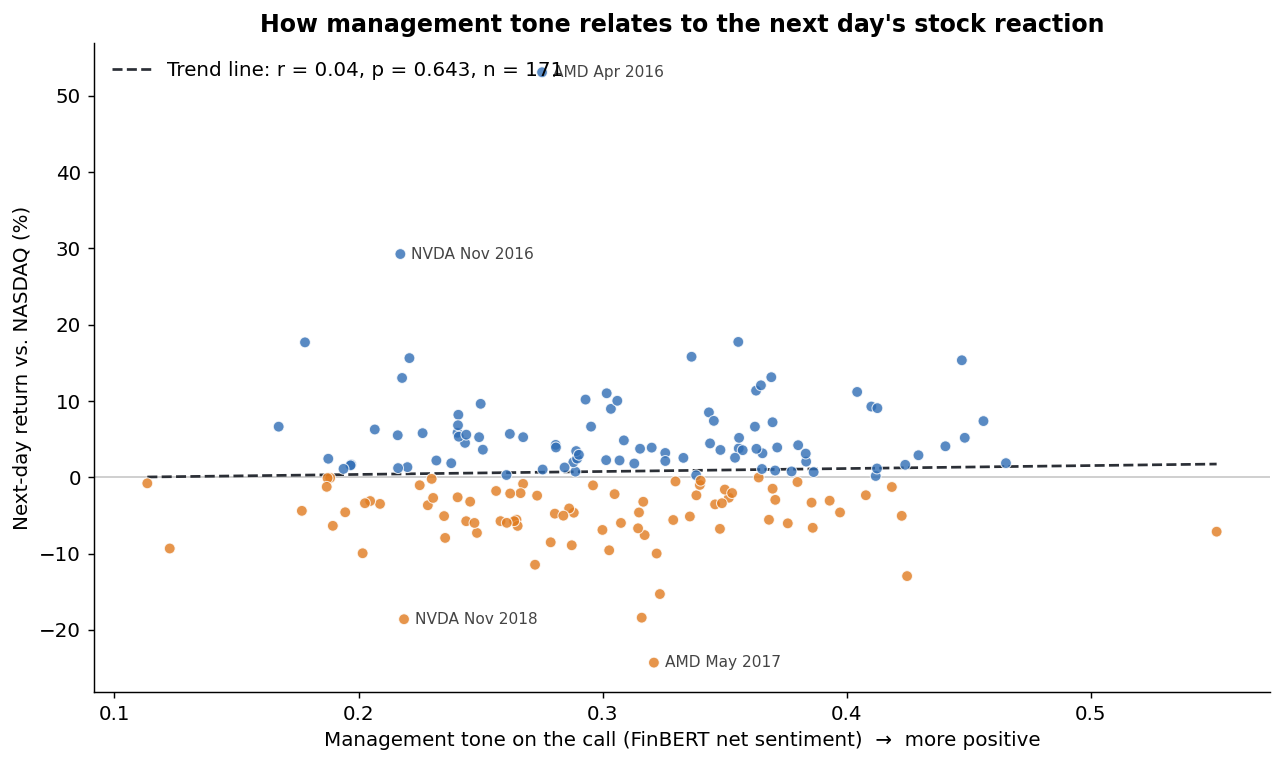

In [16]:
d = events.dropna(subset=["mgmt_tone", "abn_1d"])
x, y = d["mgmt_tone"], d["abn_1d"] * 100
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, c=np.where(y >= 0, BLUE, ORANGE), s=36, alpha=0.8, edgecolor="white", linewidth=0.6, zorder=3)
res = stats.linregress(x, y)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, res.intercept + res.slope * xs, color=DARK, linestyle="--", linewidth=1.5,
        label=f"Trend line: r = {res.rvalue:.2f}, p = {res.pvalue:.3f}, n = {len(d)}")
for _, r in d.loc[y.abs().nlargest(4).index].iterrows():
    ax.annotate(f"{r['ticker']} {r['date']:%b %Y}", (r["mgmt_tone"], r["abn_1d"] * 100),
                xytext=(6, 0), textcoords="offset points", fontsize=8.5, color="#444", va="center")
ax.axhline(0, color="#ccc", linewidth=1, zorder=1)
ax.set_xlabel("Management tone on the call (FinBERT net sentiment)  →  more positive")
ax.set_ylabel("Next-day return vs. NASDAQ (%)")
ax.set_title("How management tone relates to the next day's stock reaction")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.savefig("chart2_tone_scatter.png", dpi=200, bbox_inches="tight"); plt.show()

### Chart 3: Scripted remarks vs. live Q&A

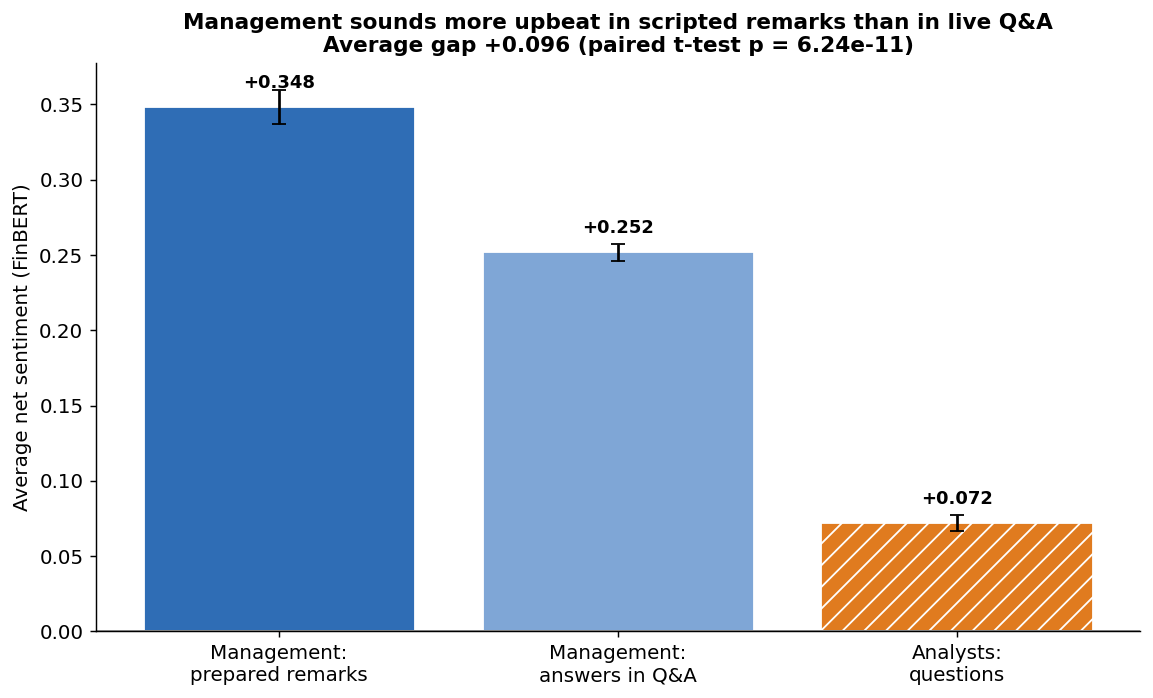

In [17]:
parts = {"Management:\nprepared remarks": events["remarks_tone"],
         "Management:\nanswers in Q&A": events["answers_tone"],
         "Analysts:\nquestions": events["analyst_tone"]}
avg = {k: v.mean() for k, v in parts.items()}
sem = {k: v.sem() for k, v in parts.items()}
drop = avg["Management:\nprepared remarks"] - avg["Management:\nanswers in Q&A"]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(list(avg), list(avg.values()), yerr=list(sem.values()), capsize=4,
              color=[BLUE, "#7FA6D6", ORANGE], edgecolor="white", hatch=["", "", "//"])
for b, v in zip(bars, avg.values()):
    ax.text(b.get_x() + b.get_width() / 2, v + (0.01 if v >= 0 else -0.01), f"{v:+.3f}",
            ha="center", va="bottom" if v >= 0 else "top", fontsize=10, fontweight="bold")
ax.axhline(0, color="#999", linewidth=1)
ax.set_ylabel("Average net sentiment (FinBERT)")
qa_test = stats.ttest_rel(events["remarks_tone"], events["answers_tone"], nan_policy="omit")
ax.set_title(("Management sounds more upbeat in scripted remarks than in live Q&A" if drop > 0
              else "Management's live Q&A answers are as upbeat as their script")
             + f"\nAverage gap {drop:+.3f} (paired t-test p = {qa_test.pvalue:.3g})", fontsize=12)
plt.tight_layout(); plt.savefig("chart3_remarks_vs_qa.png", dpi=200, bbox_inches="tight"); plt.show()

### Chart 4: Management tone over time, by company

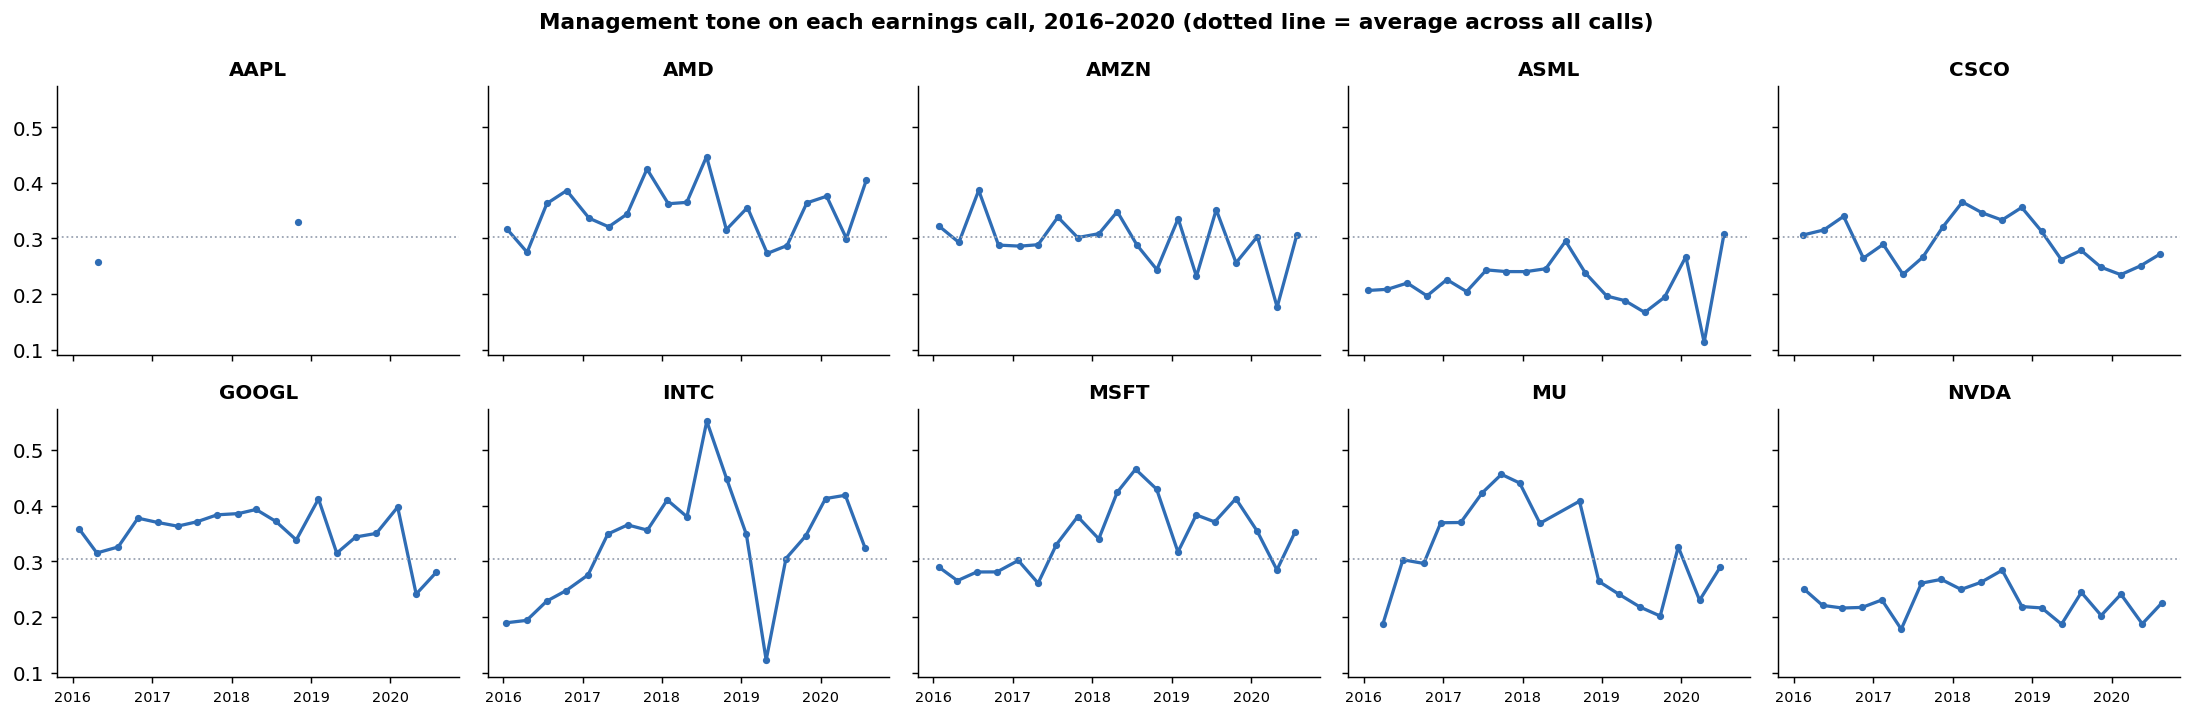

In [18]:
tickers = sorted(events["ticker"].unique())
ncols = 5; nrows = int(np.ceil(len(tickers) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 2.8 * nrows), sharey=True, sharex=True)
axes = np.atleast_1d(axes).flatten()
for ax, t in zip(axes, tickers):
    s = events[events["ticker"] == t]
    ax.plot(s["date"], s["mgmt_tone"], color=BLUE, linewidth=1.8, marker="o", markersize=3)
    ax.axhline(events["mgmt_tone"].mean(), color=GREY, linewidth=1, linestyle=":")
    ax.set_title(t, fontsize=11)
    ax.tick_params(axis="x", labelrotation=0, labelsize=8)
for ax in axes[len(tickers):]:
    ax.set_visible(False)
fig.suptitle(f"Management tone on each earnings call, {events['date'].min():%Y}–{events['date'].max():%Y} (dotted line = average across all calls)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.savefig("chart4_tone_over_time.png", dpi=200, bbox_inches="tight"); plt.show()

### Chart 5: Returns by analyst tone

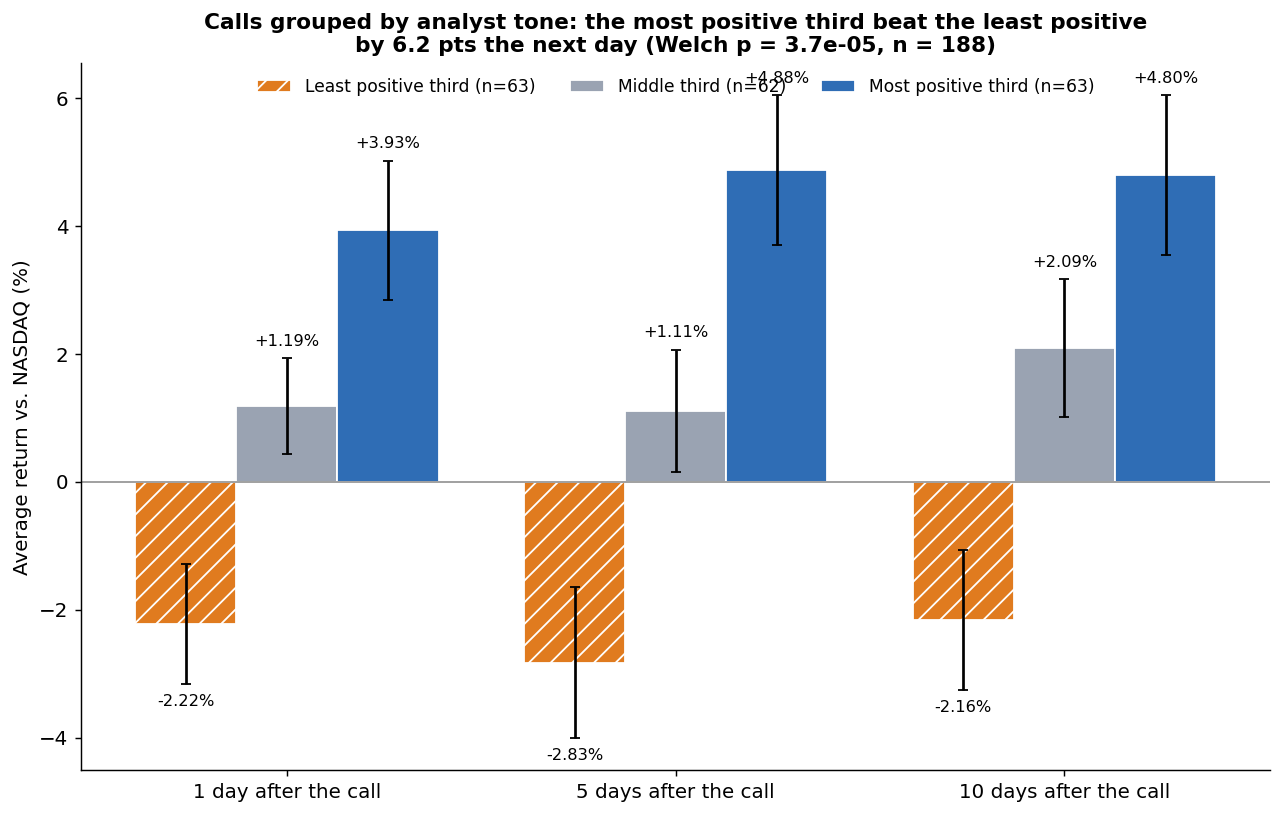

In [19]:
d = events.dropna(subset=["analyst_tone", "abn_1d"]).copy()
d["tone_group"] = pd.qcut(d["analyst_tone"], 3, labels=["Least positive third", "Middle third", "Most positive third"])
g = d.groupby("tone_group", observed=True)
means = pd.DataFrame({h: g[f"abn_{h}d"].mean() * 100 for h in HORIZONS})
sems = pd.DataFrame({h: g[f"abn_{h}d"].sem() * 100 for h in HORIZONS})

fig, ax = plt.subplots(figsize=(10, 6.4))
x = np.arange(len(HORIZONS)); w = 0.26
for k, (grp, (col, hatch)) in enumerate(zip(means.index, [(ORANGE, "//"), (GREY, ""), (BLUE, "")])):
    bars = ax.bar(x + (k - 1) * w, means.loc[grp], w, yerr=sems.loc[grp], capsize=3, color=col,
                  hatch=hatch, edgecolor="white", label=f"{grp} (n={g.size()[grp]})")
    for b, v, e in zip(bars, means.loc[grp], sems.loc[grp]):
        ax.text(b.get_x() + b.get_width() / 2, v + (e + 0.15 if v >= 0 else -e - 0.15), f"{v:+.2f}%",
                ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
ax.axhline(0, color="#999", linewidth=1)
ax.set_xticks(x); ax.set_xticklabels([f"{h} day{'s' if h > 1 else ''} after the call" for h in HORIZONS])
ax.set_ylabel("Average return vs. NASDAQ (%)")
analyst_spread = means.loc["Most positive third", 1] - means.loc["Least positive third", 1]
hi, lo = d[d["tone_group"] == "Most positive third"]["abn_1d"], d[d["tone_group"] == "Least positive third"]["abn_1d"]
welch = stats.ttest_ind(hi, lo, equal_var=False)
ax.set_title(f"Calls grouped by analyst tone: the most positive third beat the least positive\n"
             f"by {analyst_spread:.1f} pts the next day (Welch p = {welch.pvalue:.1e}, n = {len(d)})", fontsize=12)
ax.legend(frameon=False, loc="upper center", ncol=3, fontsize=9.5)
plt.tight_layout(); plt.savefig("chart5_analyst_terciles.png", dpi=200, bbox_inches="tight"); plt.show()

## 8. What did the most bullish and bearish calls sound like?
A sanity check on the model, and good talking points for interviews.

In [20]:
ranked = events.dropna(subset=["mgmt_tone"]).sort_values("mgmt_tone")
for label, subset in [("MOST POSITIVE CALLS", ranked.tail(3).iloc[::-1]), ("LEAST POSITIVE CALLS", ranked.head(3))]:
    print(f"\n{'=' * 20} {label} {'=' * 20}")
    for _, e in subset.iterrows():
        s = scores[(scores["event_id"] == e["event_id"]) & (scores["role"] == "management")]
        print(f"\n{e['title']}  |  tone {e['mgmt_tone']:+.3f}  |  next day vs NASDAQ {e['abn_1d'] * 100:+.2f}%")
        for txt in s.nlargest(2, "net")["sentence"]:  print("   +", txt[:200])
        for txt in s.nsmallest(2, "net")["sentence"]: print("   −", txt[:200])


==================== MOST POSITIVE CALLS ====================

Q2 2018 Intel Corp Earnings Call  |  tone +0.551  |  next day vs NASDAQ -7.13%
   + So yes, we expect modem profitability to improve.
   + So just maybe repeat, 27% top line growth and 65% operating income growth with an 11-point improvement in operating margins year-on-year.
   − Total spending as a percentage of revenue is down 4.6 points year-over-year in the quarter while we continue to increase investment in our key priorities.
   − And we expect a full year tax rate of roughly 12.5%, down slightly from our prior estimate.

Q4 2018 Microsoft Corp Earnings Call  |  tone +0.465  |  next day vs NASDAQ +1.86%
   + Search revenue ex TAC increased 17% and 16% in constant currency, driven by enhancements to our advertising platform and Bing volume growth across both U.S. and international markets.
   + LinkedIn revenue growth should remain high on a stronger prior year comparable.
   − Free cash flow was $7.4 billion and dow

## 9. Summary of findings

In [21]:
best = corr.loc[corr["spearman_p"].fillna(1).idxmin()]
main = corr[(corr["measure"] == "mgmt_tone") & (corr["horizon"] == "1d")].iloc[0]
print(f"Sample: {events['abn_1d'].notna().sum()} earnings calls from {events['ticker'].nunique()} NASDAQ companies, "
      f"{events['date'].min():%Y}–{events['date'].max():%Y}.")
print(f"Main test (management tone vs. next-day return vs. NASDAQ): Spearman ρ = {main['spearman_rho']:+.3f}, "
      f"p = {main['spearman_p']:.3f}.")
print(f"Most positive third of calls vs. least positive third, next day: {spread:+.2f} percentage points.")
print(f"Management tone drop from prepared remarks to live Q&A: {drop:+.3f} (paired t-test p = {qa_test.pvalue:.3g}).")
main_reg = regression_table[regression_table["specification"].str.startswith("Main, firm FE, 1d") &
                            (regression_table["term"] == "analyst_tone_z")].iloc[0]
print(f"Regression (firm FE, clustered SE): +1 s.d. of analyst tone = {main_reg['coef']:+.2f} pts next-day "
      f"abnormal return (p = {main_reg['p']:.4f}, n = {main_reg['n']}).")
print(f"Analyst-tone terciles, next day: most positive third beats least positive by {analyst_spread:.2f} pts "
      f"(Welch p = {welch.pvalue:.1e}).")
print(f"Strongest single result: {best['measure']} at {best['horizon']} "
      f"(ρ = {best['spearman_rho']:+.3f}, p = {best['spearman_p']:.3f})"
      + ("; it survives the Bonferroni correction." if best["spearman_p"] < 0.05 / N_TESTS
         else "; it does NOT survive the Bonferroni correction, so it could be chance."))

Sample: 188 earnings calls from 10 NASDAQ companies, 2016–2020.
Main test (management tone vs. next-day return vs. NASDAQ): Spearman ρ = +0.086, p = 0.263.
Most positive third of calls vs. least positive third, next day: +1.42 percentage points.
Management tone drop from prepared remarks to live Q&A: +0.096 (paired t-test p = 6.24e-11).
Regression (firm FE, clustered SE): +1 s.d. of analyst tone = +3.38 pts next-day abnormal return (p = 0.0017, n = 171).
Analyst-tone terciles, next day: most positive third beats least positive by 6.16 pts (Welch p = 3.7e-05).
Strongest single result: analyst_tone at 5d (ρ = +0.388, p = 0.000); it survives the Bonferroni correction.


## 10. Download results

In [22]:
events.to_csv("call_level_results.csv", index=False)
corr.to_csv("correlations.csv", index=False)
regression_table.to_csv("regressions.csv", index=False)
for f in ["call_level_results.csv", "correlations.csv", "regressions.csv", "sentence_scores.csv",
          "chart1_tone_terciles.png", "chart2_tone_scatter.png", "chart3_remarks_vs_qa.png", "chart4_tone_over_time.png", "chart5_analyst_terciles.png"]:
    if os.path.exists(f):
        files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Interpreting your results honestly
- **Correlation isn't causation.** Tone might predict returns only because good results cause both upbeat management *and* a rising stock.
- **Markets react to results vs. expectations** (did earnings beat analyst estimates?), which this model doesn't see. A cheerful call after a big miss can still send a stock down.
- **Ten large tech companies in 2016–2020** were mostly in a strong bull market, so results may not generalise to other sectors or periods.
- **FinBERT reads sentences in isolation.** It can miss context, sarcasm and "less bad than feared" news.
- **Ideas to extend it:** add earnings-surprise data as a control, compare FinBERT with your Claude-powered analyzer on the same calls, or test whether *analyst* tone predicts returns better than management's.

A clearly explained "weak or no relationship" is a credible finding. Explaining *why* is what impresses people.

In [23]:
import os
for f in ["regressions.csv", "chart5_analyst_terciles.png", "correlations.csv"]:
    print(f, "exists" if os.path.exists(f) else "MISSING")

regressions.csv exists
chart5_analyst_terciles.png exists
correlations.csv exists
